In this notebook we implement a simple normalizing flow with planar transforms:

In [2]:
import jax
import jax.numpy as jnp
import jax.random as random

import matplotlib.pyplot as plt
from typing import Callable
import seaborn as sns
from flax import optim, linen as nn
from modax.training import create_update
sns.set()

from jax.scipy.stats import norm
key = random.PRNGKey(42)

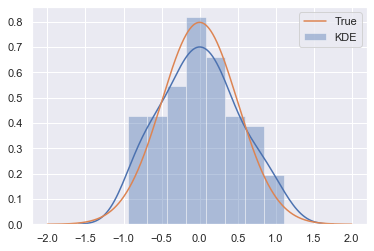

In [3]:
# Making sample dataset
n_samples = 100
n_dims = 1
x_samples = 0.5 * random.normal(key, (n_samples, n_dims))

sns.distplot(x_samples, bins='auto', label='KDE')
plt.plot(jnp.linspace(-2, 2, 1000), norm.pdf(jnp.linspace(-2, 2, 1000), loc=0.0, scale=0.5), label='True')
plt.legend()

Now let's implement a planar transform:

In [4]:
key_u, key_w, key_b = random.split(key, 3)
u = random.normal(key_u, (1, n_dims))
w = random.normal(key_w, (1, n_dims))
b = random.normal(key_b, (1, ))

params = (u, w, b)
z = x_samples

In [5]:
# normalize u s.t. w @ u >= -1; sufficient condition for invertibility
wu = w @ u.T
m_wu = -1 + jnp.log1p(jnp.exp(wu))
u_hat = u + (m_wu - wu) * w / (w @ w.T)

In [6]:
# Calculate transformed coordinates
f_z = z + u_hat * jnp.tanh(z @ w.T + b)

In [7]:
# Determining absolute log Jacobian
psi = (1 - jnp.tanh(z @ w.T + b)**2) @ w
abs_det = jnp.abs(1 + psi @ u_hat.T)
J = jnp.log(abs_det)

Text(0, 0.5, 'J')

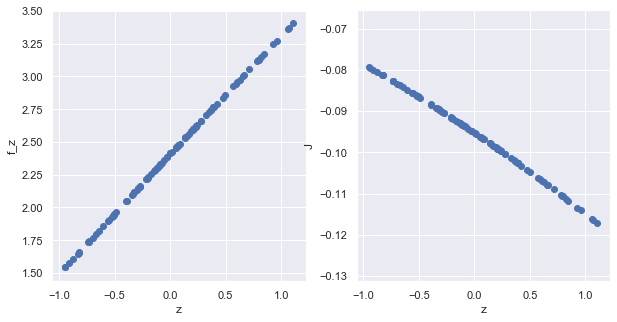

In [8]:
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(z, f_z)
plt.xlabel('z')
plt.ylabel('f_z')

plt.subplot(122)
plt.scatter(z, J)
plt.xlabel('z')
plt.ylabel('J')

Now let's put it in a function:

In [9]:
def planar_transform(z, params):
    u, w, b = params
    
    # normalize u s.t. w @ u >= -1; sufficient condition for invertibility
    wu = w @ u.T
    m_wu = -1 + jnp.log1p(jnp.exp(wu))
    u_hat = u + (m_wu - wu) * w / (w @ w.T)

    # Calculate transformed coordinates
    f_z = z + u_hat * jnp.tanh(z @ w.T + b)

    # Determining absolute log Jacobian
    psi = (1 - jnp.tanh(z @ w.T + b)**2) @ w
    abs_det = jnp.abs(1 + psi @ u_hat.T)
    log_J = jnp.log(abs_det)

    return f_z, log_J

Text(0, 0.5, 'J')

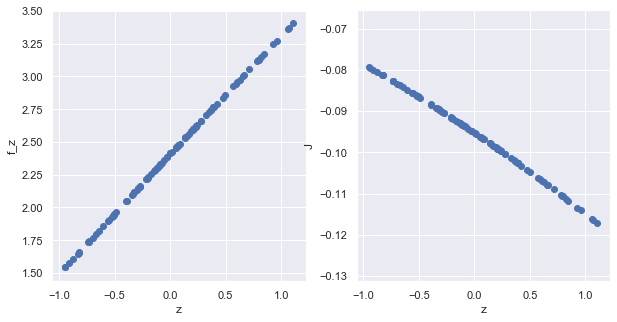

In [10]:
f_z, J = planar_transform(x_samples, params)
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(z, f_z)
plt.xlabel('z')
plt.ylabel('f_z')

plt.subplot(122)
plt.scatter(z, J)
plt.xlabel('z')
plt.ylabel('J')

Now let's turn it into a flax module:

In [11]:
class PlanarTransform(nn.Module):
    u_init: Callable = nn.initializers.lecun_normal()
    w_init: Callable = nn.initializers.lecun_normal()
    b_init: Callable = nn.initializers.zeros
    
    @nn.compact
    def __call__(self, inputs):
        n_dims = inputs.shape[1]
        u = self.param('u', self.u_init, (1, n_dims))
        w = self.param('w', self.w_init, (1, n_dims))
        b = self.param('b', self.b_init, (1, ))
        return planar_transform(inputs, (u, w, b))
        

In [12]:
# Initializing model
model = PlanarTransform()
params = model.init(key, x_samples)

Text(0, 0.5, 'J')

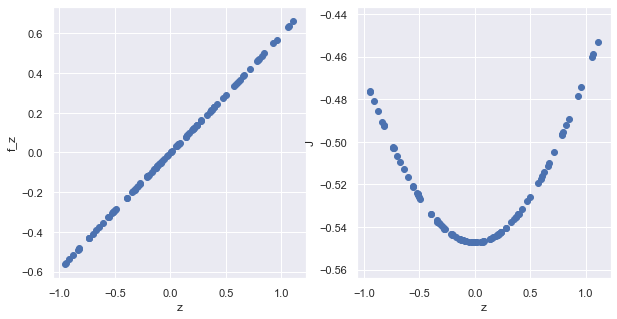

In [13]:
f_z, J = model.apply(params, x_samples)
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(z, f_z)
plt.xlabel('z')
plt.ylabel('f_z')

plt.subplot(122)
plt.scatter(z, J)
plt.xlabel('z')
plt.ylabel('J')

Nice. Now let's make it into module with multiple layers

In [14]:
class NormalizingFlow(nn.Module):
    n_layers: int
        
    @nn.compact
    def __call__(self, inputs):
        log_jacob = jnp.zeros((inputs.shape[0], 1))
        z = inputs
        for idx in jnp.arange(self.n_layers):
            z, layer_log_jacob = PlanarTransform()(z)
            log_jacob += layer_log_jacob
        return z, log_jacob
        

In [20]:
# Initializing model
model = NormalizingFlow(10)
params = model.init(key, x_samples)

Text(0, 0.5, 'J')

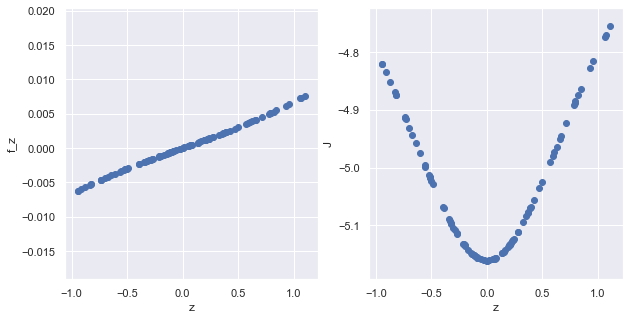

In [21]:
f_z, J = model.apply(params, x_samples)
plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.scatter(x_samples, f_z)
plt.xlabel('z')
plt.ylabel('f_z')

plt.subplot(122)
plt.scatter(x_samples, J)
plt.xlabel('z')
plt.ylabel('J')

In [22]:
def loss_fn(params, model, x, y):
    z, log_jacob = model.apply(params, x)
    loss = -jnp.sum(norm.logpdf(z) + log_jacob)
    metrics = {'loss': loss}
    return loss, metrics

In [23]:
optimizer = optim.Adam(learning_rate=1e-3)
optimizer = optimizer.create(params)

In [25]:
# Compiling train step
update = create_update(loss_fn, model=model, x=x_samples, y=x_samples)
_ = update(optimizer)  # triggering compilation

In [26]:
%%time
max_epochs = 10001
for epoch in jnp.arange(max_epochs):
    optimizer, metrics = update(optimizer)
    if epoch % 1000 == 0:
        print(f"Loss step {epoch}: {metrics['loss']}")

Loss step 0: 596.08544921875
Loss step 1000: 125.22380065917969
Loss step 2000: 82.20071411132812
Loss step 3000: 75.68707275390625
Loss step 4000: 73.60472106933594
Loss step 5000: 72.0545425415039
Loss step 6000: 70.89697265625
Loss step 7000: 70.14705657958984
Loss step 8000: 69.65377044677734
Loss step 9000: 69.38329315185547
Loss step 10000: 69.1141357421875
CPU times: user 32.2 s, sys: 9.9 s, total: 42.1 s
Wall time: 26 s


In [27]:
# Sampling from solution
x_grid = jnp.linspace(-2, 2, 1000)[:, None]
z, log_jacob = model.apply(optimizer.target, x_grid)
log_p = norm.logpdf(z) + log_jacob
p = jnp.exp(log_p)

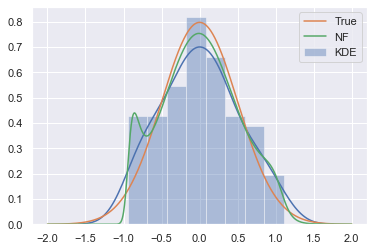

In [28]:
# Making sample dataset
n_samples = 100
n_dims = 1
x_samples = 0.5 * random.normal(key, (n_samples, n_dims))

sns.distplot(x_samples, bins='auto', label='KDE')
plt.plot(x_grid, norm.pdf(x_grid, loc=0.0, scale=0.5), label='True')
plt.plot(x_grid, p, label= 'NF')
plt.legend()

Let's collect our functions:

In [29]:
import jax.numpy as jnp
import jax.random as random
from jax.scipy.stats import norm

from flax import linen as nn

from typing import Callable


def planar_transform(z, params):
    u, w, b = params
    
    # normalize u s.t. w @ u >= -1; sufficient condition for invertibility
    wu = w @ u.T
    m_wu = -1 + jnp.log1p(jnp.exp(wu))
    u_hat = u + (m_wu - wu) * w / (w @ w.T)

    # Calculate transformed coordinates
    f_z = z + u_hat * jnp.tanh(z @ w.T + b)

    # Determining absolute log Jacobian
    psi = (1 - jnp.tanh(z @ w.T + b)**2) @ w
    abs_det = jnp.abs(1 + psi @ u_hat.T)
    log_J = jnp.log(abs_det)

    return f_z, log_J

class PlanarTransform(nn.Module):
    """Flax module for planar transform func."""
    u_init: Callable = nn.initializers.lecun_normal()
    w_init: Callable = nn.initializers.lecun_normal()
    b_init: Callable = nn.initializers.zeros
    
    @nn.compact
    def __call__(self, inputs):
        n_dims = inputs.shape[1]
        u = self.param('u', self.u_init, (1, n_dims))
        w = self.param('w', self.w_init, (1, n_dims))
        b = self.param('b', self.b_init, (1, ))
        return planar_transform(inputs, (u, w, b))
        
class NormalizingFlow(nn.Module):
    n_layers: int
        
    @nn.compact
    def __call__(self, inputs):
        log_jacob = jnp.zeros((inputs.shape[0], 1))
        z = inputs
        for idx in jnp.arange(self.n_layers):
            z, layer_log_jacob = PlanarTransform()(z)
            log_jacob += layer_log_jacob
        return z, log_jacob
        
def loss_fn(params, model, x, y):
    z, log_jacob = model.apply(params, x)
    loss = -jnp.sum(norm.logpdf(z) + log_jacob)
    metrics = {'loss': loss}
    return loss, metrics